
<p style="display:block;text-align:center;font-weight:700;font-size:40px">
  <em>Эссе №3</em>
</p>

<p style="display:block;text-align:center;font-style:italic;font-weight:700;font-size:40px">
  <em>Байесовская оценка вероятности ошибки радиоканала (BSC) по наблюдаемому битовому потоку</em>
</p>

## **Теория**

##### **Двоичный симметричный канал (Binary Symmetric Channel, BSC)**
- **Определение.** Простая модель цифровой линии связи: передаётся бит \(X \in \{0,1\}\), на выходе наблюдается бит \(Y\), и каждый бит искажается независимо с одной и той же вероятностью ошибки \(p\).
- **Вероятности переходов.**
  $$
    \Pr(Y = X) = 1 - p,\quad 
    \Pr(Y \ne X) = p.
  $$
  Матрица переходных вероятностей:
  $$
    P(y|x) = 
    \begin{pmatrix}
      \Pr(Y=0|X=0) & \Pr(Y=1|X=0) \\
      \Pr(Y=0|X=1) & \Pr(Y=1|X=1)
    \end{pmatrix}
    =
    \begin{pmatrix}
      1-p & p \\
      p & 1-p
    \end{pmatrix}.
  $$
- **Свойства.**
  - **Симметричный:** вероятность ошибки одинакова для 0 и 1.
  - **Без памяти:** ошибки по разным позициям независимы.
  - Хорошая первая модель для радиоканала с редкими независимыми ошибками битов.

---

##### **Вероятность ошибки бита и BER**
- **Вероятность ошибки бита** в модели BSC — это параметр \(p\) в формулах выше:  
  $$
    p = \Pr(Y \ne X).
  $$
- **BER (Bit Error Rate)** на практике оценивают по длинной последовательности:
$$  
    \widehat{\text{BER}} = \frac{k}{n},
  $$
  где \(k\) — число ошибочных битов (позиции, где \(Y \ne X\)), \(n\) — общее число переданных битов.
- **Интерпретация в радиосвязи.**
  - Чем меньше BER, тем «чище» канал и выше качество радиолинии.
  - BER используют для:
    - выбора схемы модуляции/кодирования (адаптация MCS);
    - мониторинга качества link’а (радиорелейки, Wi-Fi, сотовые сети);
    - тестирования линии (BERT-тестеры, измерения в лаборатории).

---

##### **Биномиальная модель числа ошибок**
- При фиксированном \(p\) и длине блока \(n\) число ошибок \(K\) (сколько раз \(Y \ne X\)) подчиняется **биномиальному распределению**:
$$  
    K \sim \mathrm{Bin}(n, p).
  $$
- **Формула вероятности**:
$$  
    \Pr(K = k \mid p) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0,1,\dots,n.
  $$
- **Связь с моделью радиоканала.**
  - Каждый бит — «независимый эксперимент»: ошибка/нет.
  - Блок из \(n\) бит — это \(n\) испытаний с вероятностью «успеха» \(p\) (здесь успех = ошибка).

---

##### **Оценка максимального правдоподобия (ML) для $p$**
- Наблюдаем:
  - переданные биты $X_1,\dots,X_n$,
  - принятые биты $Y_1,\dots,Y_n$,
  - число ошибок $k = \#\{i : X_i \ne Y_i\}$.
- При фиксированном $p$ вероятность наблюдать именно $k$ ошибок задаётся биномиальной моделью:
$$  
    \Pr(K = k \mid p) = \binom{n}{k} p^k(1-p)^{n-k}.
  $$
- **Оценка максимального правдоподобия (Maximum Likelihood, ML)** выбирает то значение \(p\), которое максимизирует эту вероятность.
- Для биномиального распределения получается простая формула:
$$  
    \hat p_{\text{ML}} = \frac{k}{n}.
  $$
- **Интерпретация.**
  - Это обычная частотная оценка BER: доля ошибочных битов.
  - При больших \(n\) \(\hat p_{\text{ML}}\) хорошо приближается к истинному \(p\), но при малых \(n\) сильно шумит (может быть даже \(0\), если ошибок не случилось).

---

##### **Байесовская оценка вероятности ошибки**
- Подход **Байеса**: считаем \(p\) неизвестным случайным параметром и задаём ему **априорное распределение** \(P(p)\), которое отражает наши ожидания до наблюдений.
- После того как мы увидели данные (количество ошибок $k$ при $n$ битах), обновляем наше мнение:
   $$
    P(p \mid k) \propto P(k \mid p)\, P(p),
  $$
  где:
  - $P(k \mid p)$ — правдоподобие (биномиальная модель),
  - $P(p)$ — априорное распределение,
  - $P(p \mid k)$ — **апостериорное распределение** (обновлённое знание о \(p\)).
- Удобный выбор априора для биномиальной модели — **бета-распределение** $\mathrm{Beta}(\alpha,\beta)$.  
  При этом:
  $$
    P(p) \propto p^{\alpha-1}(1-p)^{\beta-1}, \quad 0 < p < 1.
  $$
- Если до наблюдений мы выбираем, например, «равномерный» априор \(\mathrm{Beta}(1,1)\), то после наблюдения \(k\) ошибок из \(n\):
  $$
    P(p \mid k) = \mathrm{Beta}(\alpha', \beta'),\quad
    \alpha' = 1 + k,\quad \beta' = 1 + (n-k).
  $$
- **Байесовская точечная оценка** (например, математическое ожидание апостериорного распределения):
  $$
    \hat p_{\text{Bayes}} = \mathbb{E}[p \mid k] = \frac{\alpha'}{\alpha' + \beta'} = \frac{k+1}{n+2}
  $$
  при $\alpha=\beta=1$.
- **Плюсы байесовского подхода для радиосвязи.**
  - Дает **интервальные оценки**: можно сказать не только «\(\hat p \approx 0.01\)», но и «с 95% доверия \(p\) лежит в таком-то интервале».
  - Можно учитывать **априорное знание** о канале (например, что он обычно «хороший» и \(p\) маленькое).
  - При малом числе наблюдений байесовская оценка обычно устойчивее, чем голая частотная \(k/n\).

---

## **Практика**

In [61]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Фиксируем зерно ГПСЧ для воспроизводимости
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12


In [62]:
def generate_bits(n: int, rng=rng):
    """
    Генерирует случайную последовательность из n битов (0/1).
    """
    return rng.integers(0, 2, size=n, dtype=int)


def bsc_channel(x_bits, p: float, rng=rng):
    """
    Пропускает битовую последовательность x_bits через двоичный симметричный канал с вероятностью ошибки p.
    Возвращает принятую последовательность y_bits и вектор индикаторов ошибок.
    """
    x_bits = np.asarray(x_bits, dtype=int)
    n = x_bits.size
    
    # для каждого бита бросаем "монетку": будет ли ошибка
    error_mask = rng.random(n) < p  # True там, где произошла ошибка
    
    # ошибка реализуется как XOR с 1
    y_bits = x_bits ^ error_mask.astype(int)
    
    return y_bits, error_mask.astype(int)


In [63]:
def estimate_p_ml(x_bits, y_bits):
    """
    Оценивает вероятность ошибки по методу максимального правдоподобия (частотная оценка):
    p_hat = число ошибок / число битов.
    """
    x_bits = np.asarray(x_bits, dtype=int)
    y_bits = np.asarray(y_bits, dtype=int)
    
    assert x_bits.shape == y_bits.shape
    
    errors = (x_bits != y_bits).astype(int)
    k = errors.sum()
    n = errors.size
    p_hat = k / n if n > 0 else np.nan
    return p_hat, k, n

In [64]:
def run_single_experiment(p_true: float, n_bits: int, rng=rng):
    """
    Запускает один эксперимент:
    - генерирует n_bits случайных битов,
    - пропускает через BSC(p_true),
    - возвращает оценку p_hat_ML, число ошибок k и длину n.
    """
    x = generate_bits(n_bits, rng=rng)
    y, err_mask = bsc_channel(x, p_true, rng=rng)
    p_hat_ml, k_errors, n = estimate_p_ml(x, y)
    return p_hat_ml, k_errors, n


Посмотрим, как меняется оценка при разных длинах последовательности бит.

In [65]:
# Посмотрим, как меняется оценка при разных длинах блока
p_true = 0.05
n_list = [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]

results = []

for n_bits in n_list:
    p_hat_ml, k_errors, n = run_single_experiment(p_true, n_bits, rng=rng)
    results.append((n_bits, p_hat_ml, k_errors))
    print(f"n = {n_bits:6d} | k = {k_errors:6d} ошибок | p_hat_ML = {p_hat_ml:.4f}")

results

n =    100 | k =      6 ошибок | p_hat_ML = 0.0600
n =   1000 | k =     44 ошибок | p_hat_ML = 0.0440
n =  10000 | k =    486 ошибок | p_hat_ML = 0.0486
n = 100000 | k =   5018 ошибок | p_hat_ML = 0.0502
n = 1000000 | k =  49727 ошибок | p_hat_ML = 0.0497
n = 10000000 | k = 499516 ошибок | p_hat_ML = 0.0500


[(100, np.float64(0.06), np.int64(6)),
 (1000, np.float64(0.044), np.int64(44)),
 (10000, np.float64(0.0486), np.int64(486)),
 (100000, np.float64(0.05018), np.int64(5018)),
 (1000000, np.float64(0.049727), np.int64(49727)),
 (10000000, np.float64(0.0499516), np.int64(499516))]

Видим, что для маленьких n оценка шумная, а для больших — очень близка к p_true.   
Теперь хотим посмотреть на **разброс** оценки $\hat p_{\text{ML}}$: насколько сильно она колеблется от эксперимента к эксперименту.    


Сейчас для каждого значения $n$ мы будем делать несколько независимых прогонов
и смотреть среднее значение $\mathbb{E}[\hat p_{\text{ML}}]$ и стандартное отклонение (разброс)/

In [66]:
def collect_ml_estimates(p_true: float, n_bits_list, n_trials: int = 50, rng=rng):
    """
    Для каждого n из n_bits_list запускает n_trials независимых экспериментов
    и возвращает словарь:
      n -> массив оценок p_hat_ML длины n_trials
    """
    estimates = {}
    for n_bits in n_bits_list:
        p_hats = []
        for _ in range(n_trials):
            p_hat_ml, k_errors, n = run_single_experiment(p_true, n_bits, rng=rng)
            p_hats.append(p_hat_ml)
        estimates[n_bits] = np.array(p_hats)
    return estimates


p_true = 0.05
n_bits_list = [100, 1_000, 10_000, 100_000]
n_trials = 50

ml_estimates = collect_ml_estimates(p_true, n_bits_list, n_trials=n_trials, rng=rng)

# Посчитаем среднее и стандартное отклонение для каждого n
for n_bits in n_bits_list:
    vals = ml_estimates[n_bits]
    mean_val = vals.mean()
    std_val = vals.std()
    print(f"n = {n_bits:6d} | mean(p_hat_ML) = {mean_val:.4f} | std = {std_val:.4f}")


n =    100 | mean(p_hat_ML) = 0.0470 | std = 0.0220
n =   1000 | mean(p_hat_ML) = 0.0500 | std = 0.0061
n =  10000 | mean(p_hat_ML) = 0.0498 | std = 0.0022
n = 100000 | mean(p_hat_ML) = 0.0501 | std = 0.0007


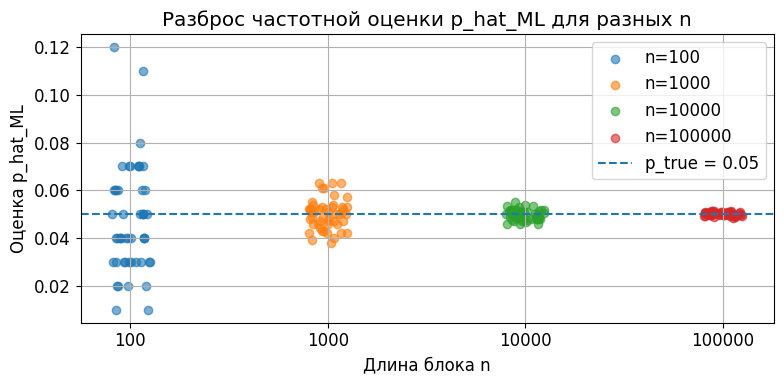

In [67]:
# Визуализируем разброс оценок: для каждого n нанесём точки p_hat_ML
plt.figure(figsize=(8,4))

for i, n_bits in enumerate(n_bits_list):
    vals = ml_estimates[n_bits]
    # Немного раздвинем точки по оси x, чтобы они не слипались
    x_coords = np.full_like(vals, fill_value=i, dtype=float) + (rng.random(size=vals.size) - 0.5) * 0.2
    plt.scatter(x_coords, vals, alpha=0.6, label=f"n={n_bits}")

# Линия истинного p_true
plt.axhline(p_true, linestyle="--", label=f"p_true = {p_true}")

plt.xticks(range(len(n_bits_list)), [str(n) for n in n_bits_list])
plt.xlabel("Длина блока n")
plt.ylabel("Оценка p_hat_ML")
plt.title("Разброс частотной оценки p_hat_ML для разных n")
plt.legend()
plt.tight_layout()
plt.show()


Теперь посмотрим, как можно оценивать $p$ в байесовском подходе.

Будем считать, что до наблюдений мы ничего не знаем о $p$ внутри $[0, 1]$  
и берём равномерное априорное распределение $P(p) = \mathrm{Beta}(1, 1)$.

Тогда, если мы наблюдали $k$ ошибок в $n$ битах, апостериорное распределение имеет вид:

$$
P(p \mid k, n) \propto p^k (1-p)^{n-k},
$$

то есть является распределением $\mathrm{Beta}(k+1, n-k+1)$.

Мы будем:

- считать $k$ и $n$ по данным эксперимента;
- строить апостериорную плотность $P(p \mid k, n)$ на сетке по $p$;
- сравнивать:
  - частотную оценку $\hat p_{\text{ML}} = k/n$,
  - байесовскую оценку (например, среднее апостериорного распределения),
  - истинное значение $p_{\text{true}}$.

In [68]:
def posterior_beta_grid(k: int, n: int, num_points: int = 1000):
    """
    Строит апостериорную плотность P(p | k, n) для равномерного априора Beta(1,1)
    на равномерной сетке по p в [0, 1].

    Возвращает:
      p_grid  -- массив значений p
      post_pdf -- нормированная плотность на этой сетке
    """
    # Сетка по p
    p_grid = np.linspace(0.0, 1.0, num_points)

    # Невнормированная плотность: p^k (1-p)^(n-k)
    
    # Добавим маленький эпсилон, чтобы избежать проблем на краях (0^0)
    eps = 1e-15
    unnorm = (p_grid + eps) ** k * (1.0 - p_grid + eps) ** (n - k)

    # Нормируем, чтобы суммарная площадь под графиком была 1
    # Используем простую дискретную нормировку как сумму * шаг
    dp = p_grid[1] - p_grid[0]
    Z = (unnorm * dp).sum()
    post_pdf = unnorm / Z if Z > 0 else np.zeros_like(unnorm)

    return p_grid, post_pdf


In [69]:
# Один эксперимент при малом числе битов
p_true = 0.05
n_bits_small = 200  # короткий блок

x_small = generate_bits(n_bits_small, rng=rng)
y_small, err_mask_small = bsc_channel(x_small, p_true, rng=rng)
p_hat_ml_small, k_small, n_small = estimate_p_ml(x_small, y_small)

print(f"[Малый блок] n = {n_small}, k = {k_small}, p_hat_ML = {p_hat_ml_small:.4f}")

p_grid_small, post_pdf_small = posterior_beta_grid(k_small, n_small, num_points=1000)

# Байесовская оценка как среднее Beta(k+1, n-k+1)
p_hat_bayes_small = (k_small + 1) / (n_small + 2)
print(f"Байесовская оценка (среднее апостериора) p_hat_Bayes = {p_hat_bayes_small:.4f}")

[Малый блок] n = 200, k = 10, p_hat_ML = 0.0500
Байесовская оценка (среднее апостериора) p_hat_Bayes = 0.0545


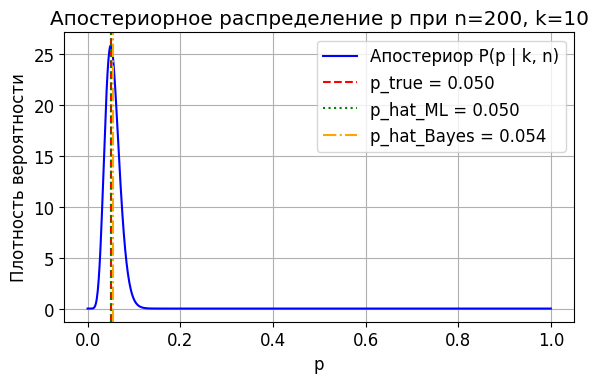

In [70]:
plt.figure()

plt.plot(p_grid_small, post_pdf_small, label="Апостериор P(p | k, n)", color="blue")
plt.axvline(p_true, linestyle="--", label=f"p_true = {p_true:.3f}", color="red")
plt.axvline(p_hat_ml_small, linestyle=":", label=f"p_hat_ML = {p_hat_ml_small:.3f}", color="green")
plt.axvline(p_hat_bayes_small, linestyle="-.", label=f"p_hat_Bayes = {p_hat_bayes_small:.3f}", color="orange")

plt.xlabel("p")
plt.ylabel("Плотность вероятности")
plt.title(f"Апостериорное распределение p при n={n_small}, k={k_small}")
plt.legend()
plt.tight_layout()
plt.show()


Для малого количества бит видим широкий пик апостериора из-за высокой степени неопределенности, а ML и Байес заметно отличаются, т к данных мало и априор имеет вес.

In [71]:
# Один эксперимент при большом числе битов
p_true = 0.05
n_bits_big = 20_000  # длинный блок

x_big = generate_bits(n_bits_big, rng=rng)
y_big, err_mask_big = bsc_channel(x_big, p_true, rng=rng)
p_hat_ml_big, k_big, n_big = estimate_p_ml(x_big, y_big)

print(f"[Большой блок] n = {n_big}, k = {k_big}, p_hat_ML = {p_hat_ml_big:.4f}")

p_grid_big, post_pdf_big = posterior_beta_grid(k_big, n_big, num_points=1000)
p_hat_bayes_big = (k_big + 1) / (n_big + 2)
print(f"Байесовская оценка (среднее апостериора) p_hat_Bayes = {p_hat_bayes_big:.4f}")


[Большой блок] n = 20000, k = 1031, p_hat_ML = 0.0515
Байесовская оценка (среднее апостериора) p_hat_Bayes = 0.0516


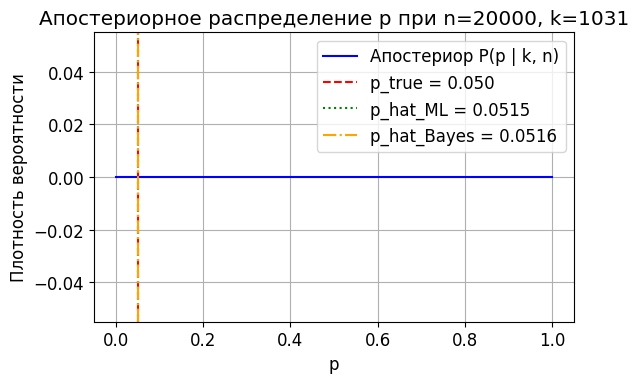

In [72]:
plt.figure()

plt.plot(p_grid_big, post_pdf_big, label="Апостериор P(p | k, n)", color="blue")
plt.axvline(p_true, linestyle="--", label=f"p_true = {p_true:.3f}", color="red")
plt.axvline(p_hat_ml_big, linestyle=":", label=f"p_hat_ML = {p_hat_ml_big:.4f}", color="green")
plt.axvline(p_hat_bayes_big, linestyle="-.", label=f"p_hat_Bayes = {p_hat_bayes_big:.4f}", color="orange")

plt.xlabel("p")
plt.ylabel("Плотность вероятности")
plt.title(f"Апостериорное распределение p при n={n_big}, k={k_big}")
plt.legend()
plt.tight_layout()
plt.show()


На таком большом объеме данных априор почти ничего не весит, и ML и Байес совпадают.   
Настоящий апостериор в теории там - узкий и высокий пик с вершиной в $0.0515$, разброс мал, т.к. имеем почти полную уверенность в параметре канала. Сам пик не видим из-за слишком маленькие числа, например, $p^{1031} (1-p)^{18969}$, они превращаются в 0 и видим лишь горизонтальную линию на нулевом уровне.

In [76]:
def compare_ml_vs_bayes(p_true: float, n_bits: int, n_trials: int = 200, rng=rng):
    """
    Для заданных p_true и n_bits многократно генерирует данные и сравнивает
    p_hat_ML и p_hat_Bayes по среднему и разбросу.
    """
    ml_vals = []
    bayes_vals = []

    for _ in range(n_trials):
        x = generate_bits(n_bits, rng=rng)
        y, _ = bsc_channel(x, p_true, rng=rng)
        p_hat_ml, k, n = estimate_p_ml(x, y)
        p_hat_bayes = (k + 1) / (n + 2)

        ml_vals.append(p_hat_ml)
        bayes_vals.append(p_hat_bayes)

    ml_vals = np.array(ml_vals)
    bayes_vals = np.array(bayes_vals)

    print(f"p_true = {p_true}, n_bits = {n_bits}")
    print(f"ML:    mean = {ml_vals.mean():.4f}, std = {ml_vals.std():.4f}")
    print(f"Bayes: mean = {bayes_vals.mean():.4f}, std = {bayes_vals.std():.4f}")

    return ml_vals, bayes_vals


p_true = 0.05
n_bits_small = 200
n_bits_big = 200_000

print("=== Малый блок ===")
ml_small, bayes_small = compare_ml_vs_bayes(p_true, n_bits_small, n_trials=300, rng=rng)

print("\n=== Большой блок ===")
ml_big, bayes_big = compare_ml_vs_bayes(p_true, n_bits_big, n_trials=300, rng=rng)


=== Малый блок ===
p_true = 0.05, n_bits = 200
ML:    mean = 0.0498, std = 0.0143
Bayes: mean = 0.0542, std = 0.0141

=== Большой блок ===
p_true = 0.05, n_bits = 200000
ML:    mean = 0.0500, std = 0.0005
Bayes: mean = 0.0501, std = 0.0005


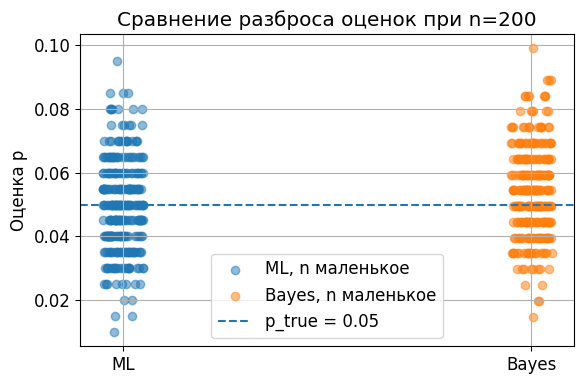

In [77]:
plt.figure()

# Немного шума по оси x, чтобы точки не легли друг на друга
x_ml_small = np.full_like(ml_small, 0, dtype=float) + (rng.random(size=ml_small.size) - 0.5) * 0.1
x_bayes_small = np.full_like(bayes_small, 1, dtype=float) + (rng.random(size=bayes_small.size) - 0.5) * 0.1

plt.scatter(x_ml_small, ml_small, alpha=0.5, label="ML, n маленькое")
plt.scatter(x_bayes_small, bayes_small, alpha=0.5, label="Bayes, n маленькое")

plt.axhline(p_true, linestyle="--", label=f"p_true = {p_true}")

plt.xticks([0, 1], ["ML", "Bayes"])
plt.ylabel("Оценка p")
plt.title(f"Сравнение разброса оценок при n={n_bits_small}")
plt.legend()
plt.tight_layout()
plt.show()


При маленьком $n$:
- оценки и ML, и Bayes сильно гуляют от эксперимента к эксперименту (от 0.01 до 0.1),
- один короткий пакет даёт довольно ненадёжную оценку BER,
- Bayes чуть сглаживает оценку за счёт априора, но разброс всё равно большой.

Посмотрим то же самое при большом n

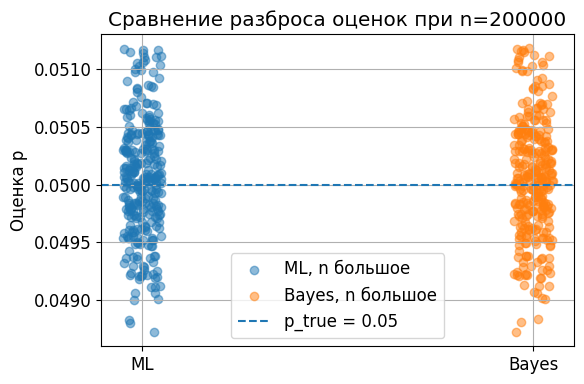

In [79]:
plt.figure()

# Немного шума по оси x, чтобы точки не легли друг на друга
x_ml_big = np.full_like(ml_big, 0, dtype=float) + (rng.random(size=ml_big.size) - 0.5) * 0.1
x_bayes_big = np.full_like(bayes_big, 1, dtype=float) + (rng.random(size=bayes_big.size) - 0.5) * 0.1

plt.scatter(x_ml_big, ml_big, alpha=0.5, label="ML, n большое")
plt.scatter(x_bayes_big, bayes_big, alpha=0.5, label="Bayes, n большое")

plt.axhline(p_true, linestyle="--", label=f"p_true = {p_true}")

plt.xticks([0, 1], ["ML", "Bayes"])
plt.ylabel("Оценка p")
plt.title(f"Сравнение разброса оценок при n={n_bits_big}")
plt.legend()
plt.tight_layout()
plt.show()

При очень большом $n$:
- разброс оценок резко уменьшается, облака сжимаются вокруг $p_{\text{true}}$,
- ML и Bayes практически неотличимы — приёмник «точно знает» параметр канала,
- выбор метода оценки уже почти не важен, важен объём наблюдений.

Итак, на коротких блоках обе оценки BER сильно шумят, а на длинных объёмах данных разброс стремительно падает, и ML и байесовская оценка фактически совпадают. Для надёжной оценки качества радиолинии критично иметь достаточно длинный наблюдаемый поток.

## **Результаты и применимость**

####  Краткие выводы экспериментов

- Для маленького блока ($n=200$) оценки $p$ сильно шумят, апостериор широкий → про канал знаем мало.
- Для большого блока ($n=20000$) $\hat p_{\text{ML}}$ и $\hat p_{\text{Bayes}}$ почти совпадают, апостериор узкий → параметр канала оценён точно.
- Байесовская оценка чуть сглаживает результат при малом $n$ и не даёт экстремальных значений вроде $0$.



#### Как это можно использовать

- **Онлайн-оценка BER.**  
  Точно так же оценивают качество радиолинии по пилотам/служебным данным, чтобы выбирать модуляцию, код и решать, нужны ли ретрансмиссии.

- **Короткие пакеты.**  
  При малом числе бит обычная оценка $k/n$ может сильно прыгать. Байес даёт более стабильное значение и понятный диапазон правдоподобных $p$.

- **Планирование измерений.**  
  По сужению апостериора видно, сколько бит нужно прогнать через канал, чтобы оценить BER с нужной точностью.

Модель BSC простая, но даёт реалистичную схему оценки качества линка и легко обобщается на более сложные каналы.


### 4.2. Практическая польза для радиосистем

1. **Онлайн-оценка качества канала (BER-оценка по пилотам и служебным данным)**  
   Математическая модель BSC и реализованные оценки $p$ соответствуют тому, что делают реальные приёмники:
   по известным битовым последовательностям (пилоты, CRC, тестовые паттерны) оценивают BER линии и принимают
   решения о:
   - выборе схемы модуляции и кодирования (MCS, AMC);
   - необходимости повторной передачи (ARQ/Hybrid ARQ);
   - переключении на другой канал/частоту/базовую станцию.

2. **Режимы с малой задержкой и короткими пакетами**  
   В сценариях URLLC, управления, телеметрии и т.п. пакеты короткие, статистики мало, и чистая оценка
   $\hat p_{\text{ML}} = k/n$ может сильно прыгать (например, $k=0 \Rightarrow \hat p_{\text{ML}} = 0$).  
   Байесовский подход:
   - даёт адекватную ненулевую оценку даже при отсутствии ошибок в текущем пакете;
   - позволяет аккумулировать знания из прошлых наблюдений через априор.

3. **Интервальные оценки качества линка**  
   Вместо одной цифры BER можно получать **диапазон правдоподобных значений** $p$ (credible interval).
   Это важно при принятии решений:
   - стоит ли агрессивно повышать скорость передачи, если мы уверены в низком BER;
   - или, наоборот, нужно сначала накопить больше статистики, если апостериор ещё широк.

4. **Планирование тестов и измерений**  
   Модель показывает, как быстро уменьшается неопределённость при росте числа бит:
   - можно оценить, сколько тестовых данных нужно прогнать через линию, чтобы оценить BER с заданной точностью;
   - помогает проектировать режимы BERT-тестирования и длительность измерений в лаборатории/полевых испытаниях.

---

### 4.3. Ограничения и расширения

- Модель BSC предполагает независимые ошибки и одинаковую вероятность для 0 и 1. В реальных каналах
  часто появляются burst-ошибки, асимметрия и зависимость от уровня сигнала (SNR).
- Тем не менее, этот подход легко расширяется:
  - на бинарные каналы с асимметрией;
  - на многозначные алфавиты (символы модуляции QAM/PSK);
  - на модели, где параметр $p$ зависит от скрытого состояния канала (фединговые каналы, медленно меняющийся SNR).

Таким образом, даже простая байесовская оценка параметра $p$ в модели BSC даёт полезную интуицию и
инструменты, которые напрямую применимы при анализе и управлении качеством цифровых радиолиний.






## **Литература**

https://ru.wikipedia.org/wiki/Двоичный_симметричный_канал   
https://ru.wikipedia.org/wiki/Пропускная_способность_канала   
https://en.wikipedia.org/wiki/Bit_error_rate    
https://habr.com/ru/articles/251693/   
https://ru.wikipedia.org/wiki/Биномиальное_распределение     
https://ru.wikipedia.org/wiki/Байесовский_вывод 

